<a href="https://colab.research.google.com/github/hwasun-zip/fintech-cohort-funnel-sql/blob/main/fintech_cohort_funnel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip -q install kagglehub

from google.colab import files
import os

uploaded = files.upload()          # kaggle 파일 선택
fname = list(uploaded.keys())[0]   # 실제 올라간 파일 이름 자동 인식
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename(fname, '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('업로드 완료! (원본 파일명:', fname, ')')

Saving kaggle (1).json to kaggle (1) (1).json
업로드 완료! (원본 파일명: kaggle (1) (1).json )


In [5]:
import kagglehub, glob, os
path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
print('저장 경로:', path)
for f in sorted(glob.glob(path + '/*.csv')):
    print(' -', os.path.basename(f))

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
저장 경로: /kaggle/input/brazilian-ecommerce
 - olist_customers_dataset.csv
 - olist_geolocation_dataset.csv
 - olist_order_items_dataset.csv
 - olist_order_payments_dataset.csv
 - olist_order_reviews_dataset.csv
 - olist_orders_dataset.csv
 - olist_products_dataset.csv
 - olist_sellers_dataset.csv
 - product_category_name_translation.csv


In [6]:
import pandas as pd, sqlite3

orders    = pd.read_csv(f'{path}/olist_orders_dataset.csv')
customers = pd.read_csv(f'{path}/olist_customers_dataset.csv')
payments  = pd.read_csv(f'{path}/olist_order_payments_dataset.csv')

con = sqlite3.connect('olist.db')          # olist.db 라는 DB 파일 생성
orders.to_sql('orders', con, if_exists='replace', index=False)
customers.to_sql('customers', con, if_exists='replace', index=False)
payments.to_sql('order_payments', con, if_exists='replace', index=False)

def q(sql):                                # 앞으로 이 함수로 SQL 실행
    return pd.read_sql_query(sql, con)

print('적재 완료:', len(orders), '주문 /', len(customers), '고객행 /', len(payments), '결제행')

적재 완료: 99441 주문 / 99441 고객행 / 103886 결제행


In [7]:
q("""
SELECT COUNT(*)                        AS 총_행수,
       COUNT(DISTINCT customer_id)     AS customer_id_수,
       COUNT(DISTINCT customer_unique_id) AS 진짜_고객수
FROM customers
""")

,총_행수,customer_id_수,진짜_고객수
0,99441,99441,96096


In [8]:
q("""
SELECT order_status, COUNT(*) AS cnt
FROM orders
GROUP BY order_status
ORDER BY cnt DESC
""")

,order_status,cnt
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [9]:
#이행 퍼널 산출
funnel = q("""
SELECT
  COUNT(*) AS purchased,
  SUM(CASE WHEN order_approved_at             IS NOT NULL THEN 1 ELSE 0 END) AS approved,
  SUM(CASE WHEN order_delivered_carrier_date  IS NOT NULL THEN 1 ELSE 0 END) AS shipped,
  SUM(CASE WHEN order_delivered_customer_date IS NOT NULL THEN 1 ELSE 0 END) AS delivered
FROM orders
""").T.reset_index()
funnel.columns = ['stage', 'count']
funnel['pct_of_top']   = (funnel['count'] / funnel['count'].iloc[0] * 100).round(1)
funnel['step_dropoff'] = (funnel['count'].shift(1) - funnel['count']).fillna(0).astype(int)
funnel

,stage,count,pct_of_top,step_dropoff
0,purchased,99441,100.0,0
1,approved,99281,99.8,160
2,shipped,97658,98.2,1623
3,delivered,96476,97.0,1182


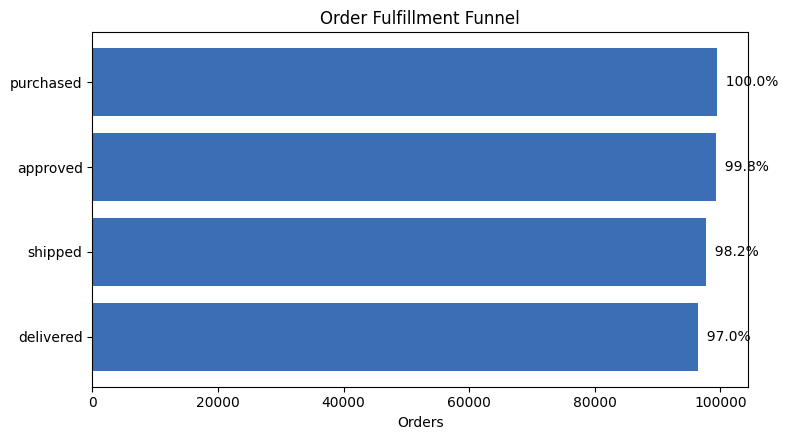

In [10]:
#퍼널 차트
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(funnel['stage'][::-1], funnel['count'][::-1], color='#3b6fb5')
for b, pct in zip(bars, funnel['pct_of_top'][::-1]):
    ax.text(b.get_width(), b.get_y()+b.get_height()/2, f'  {pct:.1f}%', va='center')
ax.set_title('Order Fulfillment Funnel'); ax.set_xlabel('Orders')
plt.tight_layout(); plt.savefig('funnel.png', dpi=120); plt.show()

In [11]:
#월별 코호트 리텐션 산출
cohort = q("""
WITH valid_orders AS (
    SELECT c.customer_unique_id AS uid,
           strftime('%Y-%m-01', o.order_purchase_timestamp) AS order_month
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status <> 'canceled'
      AND o.order_purchase_timestamp IS NOT NULL
),
first_order AS (
    SELECT uid, MIN(order_month) AS cohort_month
    FROM valid_orders GROUP BY uid
),
activity AS (
    SELECT DISTINCT uid, order_month AS active_month FROM valid_orders
),
joined AS (
    SELECT f.cohort_month, a.uid,
           (CAST(strftime('%Y', a.active_month) AS INT)*12 + CAST(strftime('%m', a.active_month) AS INT))
         - (CAST(strftime('%Y', f.cohort_month) AS INT)*12 + CAST(strftime('%m', f.cohort_month) AS INT)) AS month_number
    FROM first_order f
    JOIN activity a ON f.uid = a.uid
)
SELECT cohort_month, month_number, COUNT(DISTINCT uid) AS active_customers
FROM joined
GROUP BY cohort_month, month_number
ORDER BY cohort_month, month_number
""")
cohort.head()

,cohort_month,month_number,active_customers
0,2016-09-01,0,2
1,2016-10-01,0,297
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1


In [12]:
#리텐션 %(피벗)로 변환
pivot = cohort.pivot(index='cohort_month', columns='month_number', values='active_customers')
retention = pivot.divide(pivot[0], axis=0) * 100
retention.round(1).iloc[:, :7]   # M0~M6

month_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.3
2016-12-01,100.0,100.0,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.4,0.3,0.1,0.4,0.1,0.5
2017-02-01,100.0,0.2,0.3,0.1,0.4,0.1,0.2
2017-03-01,100.0,0.5,0.3,0.4,0.3,0.2,0.2
2017-04-01,100.0,0.6,0.2,0.2,0.3,0.3,0.3
2017-05-01,100.0,0.5,0.5,0.4,0.3,0.3,0.4
2017-06-01,100.0,0.4,0.4,0.4,0.3,0.4,0.4


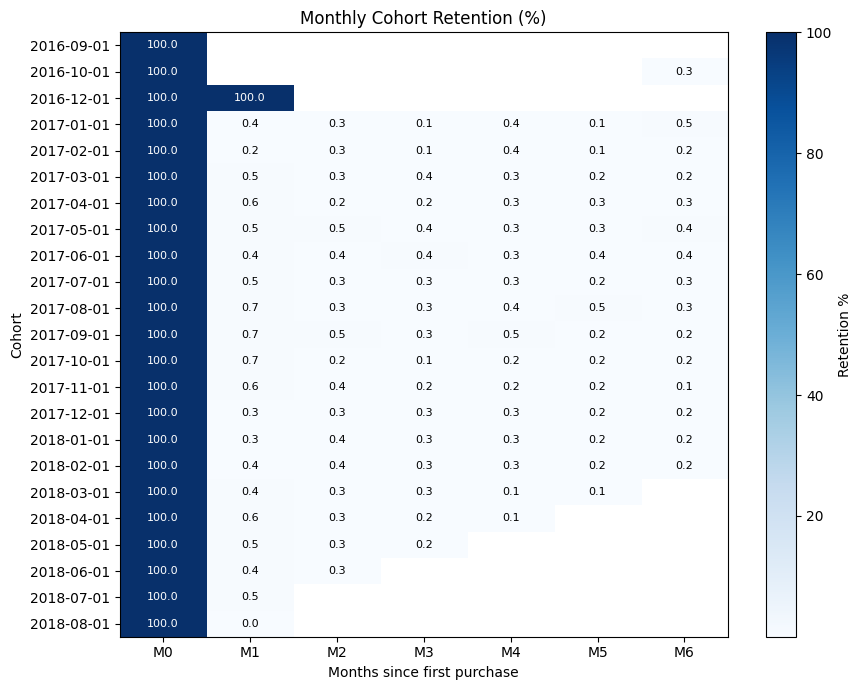

In [13]:
#리텐션 히트맵
import numpy as np
m = retention.iloc[:, :7]
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(m.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(m.shape[1])); ax.set_xticklabels([f'M{c}' for c in m.columns])
ax.set_yticks(range(m.shape[0])); ax.set_yticklabels(m.index)
ax.set_xlabel('Months since first purchase'); ax.set_ylabel('Cohort')
ax.set_title('Monthly Cohort Retention (%)')
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    color='white' if v > 40 else 'black', fontsize=8)
plt.colorbar(im, label='Retention %'); plt.tight_layout(); plt.savefig('retention_heatmap.png', dpi=120); plt.show()

In [14]:
#재구매율
q("""
WITH order_cnt AS (
    SELECT c.customer_unique_id AS uid, COUNT(*) AS n_orders
    FROM orders o JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status <> 'canceled'
    GROUP BY c.customer_unique_id
)
SELECT COUNT(*) AS total_customers,
       SUM(CASE WHEN n_orders >= 2 THEN 1 ELSE 0 END) AS repeat_customers,
       ROUND(100.0 * SUM(CASE WHEN n_orders >= 2 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_rate_pct
FROM order_cnt
""")

,total_customers,repeat_customers,repeat_rate_pct
0,95560,2924,3.06
